# Parte 3: Entrenamiendo y ejecución de modelo por el Método 2

En éste código se va a entrenar el modelo usando los datos con oversampling y mediante capas convolucionales, de pooling, flatten y red neuronal artificial simple.

In [16]:
#Importación de las librerías necesarias
import warnings
warnings.filterwarnings('ignore')
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPool2D, Dropout, BatchNormalization

from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.preprocessing import image
from tensorflow.keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau
import gc
import os
import multiprocessing

Leemos el archivo de Películas con imagen, el cual obtuvimos en la parte 2 del preprocesamiento.

In [17]:
with open('C:/Users/clau_/OneDrive/Documentos/FCFM/03_Tetramestre/Aprendizaje_Profundo/PIA/Películas con imagen.csv', encoding='utf-8') as f:
        movies = pd.read_csv(f, sep=',')

In [18]:
movies.sample(5)

,index,imdbID,Genre,Poster,Action,Adventure,Animation,Comedy,Crime,Drama,Family,Fantasy,Horror,Music,Mystery,Romance,Sci-Fi,Sport,Thriller,Existe
20344,20468,tt0129922,"Drama,Mystery",https://m.media-amazon.com/images/M/MV5BNDhlZW...,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1
3207,3236,tt0076516,"Adventure,Horror,Thriller",https://m.media-amazon.com/images/M/MV5BOTVmZD...,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,1
34551,34832,tt0490076,"Horror,Mystery,Thriller",https://m.media-amazon.com/images/M/MV5BMzM0Mj...,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,1
13127,13211,tt0099346,"Crime,Drama",https://m.media-amazon.com/images/M/MV5BOWMzZD...,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1
11953,12033,tt0095507,Drama,https://m.media-amazon.com/images/M/MV5BYTQ1Ym...,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1


A continucación realizaremos el oversampling para balancear la cantidad de registros por cada género.

In [21]:
generos_separados = movies['Genre'].str.get_dummies(sep=',')
generos_separados.sum()

Action        7141
Adventure     3900
Animation     1622
Comedy       14358
Crime         5755
Drama        22302
Family        2730
Fantasy       2293
Horror        6521
Music         2204
Mystery       3062
Romance       5020
Sci-Fi        2881
Sport         1471
Thriller      7489
dtype: int64

In [22]:
movies_copy = movies.copy()

In [23]:
len(movies)

47756

In [28]:
#Lo fraccionamos para obtener una muestra más pequeña
movies = movies.sample(frac=.4)
movies = movies.sample(frac=.4)
movies_copy = pd.concat([movies, movies_copy]).drop_duplicates(keep=False)

In [29]:
#Obtenemos los diferentes géneros
label_dict = {"word2idx": {}, "idx2word": []}
idx = 0
genre_per_movie = movies["Genre"].apply(lambda x: str(x).split(",")[:-1])
for l in [g for d in genre_per_movie for g in d]:
    if l in label_dict["idx2word"]:
        pass
    else:
        label_dict["idx2word"].append(l)
        label_dict["word2idx"][l] = idx
        idx += 1
n_classes = len(label_dict["idx2word"])

In [26]:
#Función que imprime cada género con su cantidad de registros
def genre_count(df, label_dict):
    max_genre = 0
    for label in label_dict["idx2word"]:
        occurrences = len((df[df['Genre'].str.contains(label)]))
        print(label, occurrences)
        if occurrences > max_genre:
            max_genre = occurrences
    return max_genre

In [30]:
#Imprimimos cómo está ya con el fraccionado
max_genre = genre_count(movies, label_dict)

Comedy 2276
Family 428
Action 1100
Drama 3556
Crime 904
Adventure 606
Horror 1053
Mystery 506
Animation 255
Fantasy 371
Music 351
Romance 816
Thriller 1243
Sci-Fi 458
Sport 237


In [31]:
# Descartamos drama y comedia, puesto que son los géneros con mayor cantidad
movies_copy = movies_copy[~movies_copy["Genre"].str.contains("Comedy")]
movies_copy = movies_copy[~movies_copy["Genre"].str.contains("Drama")]
    
for label in label_dict["idx2word"]:
    if label not in ["Drama", "Comedy"]:
        len_genre = len(movies[movies['Genre'].str.contains(label)])
        df_genre = movies_copy[movies_copy['Genre'].str.contains(label)]
        #df_genre['genres'] = [label+"|" for i in range (0, len(df_genre))]    
        if (max_genre - len_genre) > 0:
            if len_genre > 2000:
                param = 0
            elif len_genre > 1000:
                param = 0.3
            elif len_genre > 500:
                param = 0.5
            else:
                param = 0.9
            df_class_over = df_genre.sample(int((max_genre-len_genre)*param)+1, replace=True)
            movies = pd.concat([movies, df_class_over], axis=0)

print('Random over-sampling:')
print(genre_count(movies, label_dict))

Random over-sampling:
Comedy 2276
Family 3916
Action 3954
Drama 3556
Crime 2245
Adventure 3144
Horror 3092
Mystery 2397
Animation 2019
Fantasy 2156
Music 2102
Romance 1820
Thriller 3146
Sci-Fi 1946
Sport 3231
3954


Una vez aplicado el oversampling y que los números y porcentajes se vean más balanceados, se guarda en un csv para usarse en el método 4.

In [68]:
movies.to_csv("Películas Oversampling.csv", index=False)

In [33]:
movies.shape

(21730, 18)

In [34]:
movies.reset_index(inplace = True)

In [35]:
movies.sample(5)

,index,imdbID,Genre,Poster,Action,Adventure,Animation,Comedy,Crime,Drama,Family,Fantasy,Horror,Music,Mystery,Romance,Sci-Fi,Sport,Thriller
2066,25979,tt0312408,Drama,https://m.media-amazon.com/images/M/MV5BMTY5OT...,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
20133,42273,tt7636896,Sport,https://m.media-amazon.com/images/M/MV5BOTA1Zj...,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
20172,36811,tt9211386,Sport,https://m.media-amazon.com/images/M/MV5BY2I1Yz...,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
9381,38600,tt8688048,Family,https://m.media-amazon.com/images/M/MV5BNTY4OD...,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
3991,35884,tt9575160,"Crime,Drama,Mystery",https://m.media-amazon.com/images/M/MV5BMWJkMD...,0,0,0,0,1,1,0,0,0,0,1,0,0,0,0


Vamos a buscar el archivo .jpg de cada película para ingresarla a una lista de imágenes.

In [36]:
#Definimos el array donde se van a ir guardando las imágenes
imagenes = []
# Imprimir los nombres de los archivos
for i in tqdm(range(movies.shape[0])):
    archivo = movies['imdbID'][i]
    path = "C:/Users/clau_/OneDrive/Documentos/FCFM/03_Tetramestre/Aprendizaje_Profundo/PIA/Posters/" + archivo + '.jpg'
    #Leemos la imagen
    imagen = image.load_img(path, target_size=(250, 250))
    imagen = image.img_to_array(imagen)
    imagen = imagen / 255
    #Agregamos la imagen a la lista de imágenes
    imagenes.append(imagen)

100%|██████████| 21730/21730 [02:02<00:00, 177.46it/s]


Las imágenes las ingresamos en el array que conforma las x, que será la variable dependiente. Este será un array de 4 dimensiones.

In [37]:
x = np.array(imagenes)

In [38]:
x.shape

(21730, 250, 250, 3)

In [39]:
#Borramos el array de imágenes para liberar espacio en RAM
del imagenes

Validamos que el índice corresponda a la imagen y su asignación.

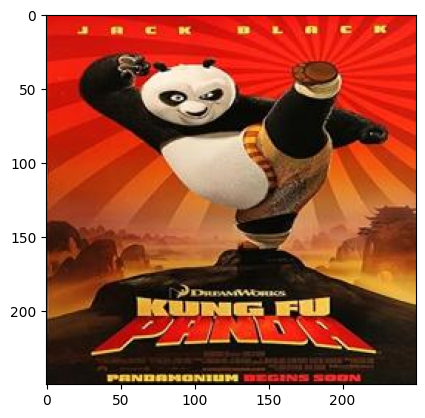

In [40]:
plt.imshow(x[14568])

In [41]:
movies.iloc[14568]

index                                                    31925
imdbID                                               tt0441773
Genre                               Animation,Action,Adventure
Poster       https://m.media-amazon.com/images/M/MV5BODJkZT...
Action                                                       1
Adventure                                                    1
Animation                                                    1
Comedy                                                       0
Crime                                                        0
Drama                                                        0
Family                                                       0
Fantasy                                                      0
Horror                                                       0
Music                                                        0
Mystery                                                      0
Romance                                                

Una vez validado, se inserta en la variable y lo correspondiente a solo las columnas de los géneros, que son 15. Eliminamos las columnas que no nos sirven.

In [42]:
#Ahora con las y
y = movies.drop(columns = ['imdbID', 'Genre', 'Poster', 'index'])
y = y.to_numpy()
print(y.shape), print(type(y))

(21730, 15)
<class 'numpy.ndarray'>


(None, None)

# Entrenamiento del modelo

Realizamos el split de entrenamiento y prueba con un 80-20.

In [43]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.20)

In [44]:
#Borramos la x para liberar espacio en RAM
del x

In [45]:
X_train[0].shape

(250, 250, 3)

Vamos a definir las capas del modelo.

In [46]:
#Modelo secuencial
model = Sequential()

#Primera capa convolucional
model.add(Conv2D(16, (3, 3), activation='relu', input_shape= (250, 250, 3)))
#Primera capa de pooling
model.add(MaxPool2D(2,2))

#Segunda capa convolucional
model.add(Conv2D(32, (3, 3), activation='relu'))
#Segunda capa de pooling
model.add(MaxPool2D(2,2))

#Tercera capa convolucional
model.add(Conv2D(64, (3, 3), activation='relu'))
#Tercera capa de pooling
model.add(MaxPool2D(2,2))

#Cuarta capa convolucional
model.add(Conv2D(128, (3, 3), activation='relu'))
#Cuarta capa de pooling
model.add(MaxPool2D(2,2))

#Capa de aplanado
model.add(Flatten())

#Primera capa de ANN
model.add(Dense(64, activation='relu'))
#Segunda capa de ANN
model.add(Dense(128, activation='relu'))
#Capa de salida de ANN
model.add(Dense(15, activation='sigmoid'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 248, 248, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 124, 124, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 122, 122, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 61, 61, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 59, 59, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 29, 29, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 27, 27, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 21632)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,384,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,492,207 (5.69 MB)

 Trainable params: 1,492,207 (5.69 MB)

 Non-trainable params: 0 (0.00 B)

In [47]:
#Limpiamos para liberar espacio en RAM
gc.collect()

115

In [49]:
#Se compila
model.compile(loss='binary_crossentropy', metrics=['accuracy'], optimizer='adam')

In [50]:
#Se entrena el modelo
history = model.fit(X_train, y_train, batch_size=25, epochs=15, validation_data=(X_test, y_test))

Epoch 1/15
696/696 ━━━━━━━━━━━━━━━━━━━━ 260s 368ms/step - accuracy: 0.1401 - loss: 0.3764 - val_accuracy: 0.1744 - val_loss: 0.3516
Epoch 2/15
696/696 ━━━━━━━━━━━━━━━━━━━━ 251s 360ms/step - accuracy: 0.2115 - loss: 0.3446 - val_accuracy: 0.2526 - val_loss: 0.3174
Epoch 3/15
696/696 ━━━━━━━━━━━━━━━━━━━━ 250s 359ms/step - accuracy: 0.3083 - loss: 0.2898 - val_accuracy: 0.3306 - val_loss: 0.2711
Epoch 4/15
696/696 ━━━━━━━━━━━━━━━━━━━━ 251s 360ms/step - accuracy: 0.4345 - loss: 0.2100 - val_accuracy: 0.3672 - val_loss: 0.2486
Epoch 5/15
696/696 ━━━━━━━━━━━━━━━━━━━━ 251s 361ms/step - accuracy: 0.5154 - loss: 0.1446 - val_accuracy: 0.4135 - val_loss: 0.2493
Epoch 6/15
696/696 ━━━━━━━━━━━━━━━━━━━━ 251s 361ms/step - accuracy: 0.5741 - loss: 0.1049 - val_accuracy: 0.4112 - val_loss: 0.2724
Epoch 7/15
696/696 ━━━━━━━━━━━━━━━━━━━━ 263s 377ms/step - accuracy: 0.6063 - loss: 0.0804 - val_accuracy: 0.4413 - val_loss: 0.2954
Epoch 8/15
696/696 ━━━━━━━━━━━━━━━━━━━━ 263s 378ms/step - accuracy: 0.6102 -

Una vez entrenado el modelo, vamos a hacer la predición del 20% de prueba.

In [51]:
pred = model.predict(X_test)

136/136 ━━━━━━━━━━━━━━━━━━━━ 17s 121ms/step


Comparamos los valores de Accuracy y Loss versus Val_Accuracy y Val_loss

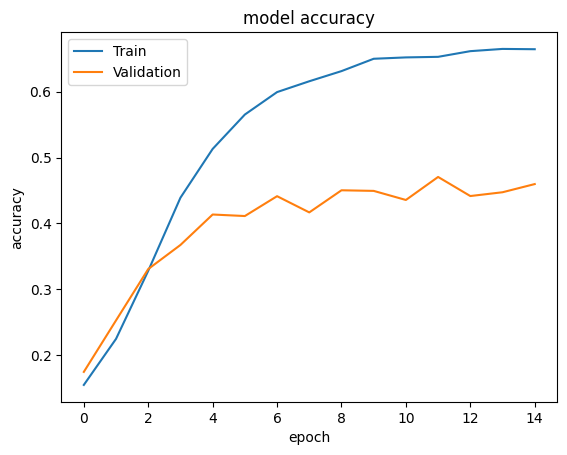

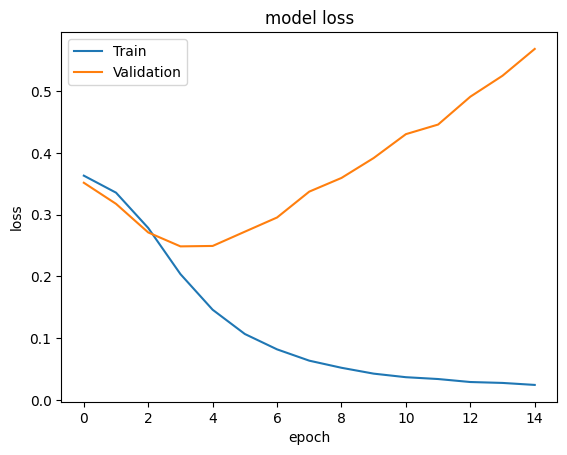

In [52]:
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

Se imprime un ejemplo con un umbral del 40%

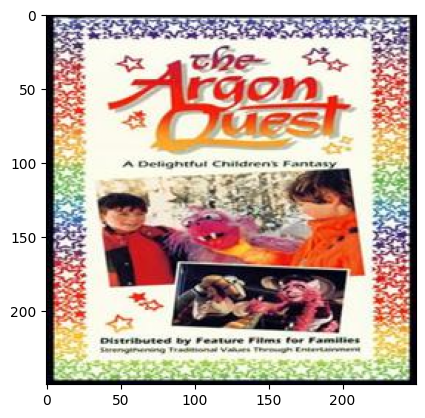

In [55]:
plt.imshow(X_test[1458])

In [56]:
print(y_test[1458])

[0 1 0 0 0 0 1 1 0 0 0 0 0 0 0]


In [57]:
umbral = 0.4
y_pred_binarizado = np.where(pred > umbral, 1, 0)

In [58]:
print(y_pred_binarizado[1458])

[0 1 0 0 0 0 1 1 0 0 0 0 0 0 0]


Por último, calculamos las métricas para la comparativa.

In [60]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, hamming_loss, jaccard_score

In [62]:
#Arriba del 30% de probabilidad, se toma como éxito
umbral = 0.3
y_pred_binarizado = np.where(pred > umbral, 1, 0)

In [63]:
# Exactitud (Accuracy)
accuracy = accuracy_score(y_test, y_pred_binarizado)
print("Exactitud (Accuracy):", accuracy)

# Precisión (Precision)
precision_micro = precision_score(y_test, y_pred_binarizado, average='micro')
print("Precisión (Precision) - Micro:", precision_micro)

precision_macro = precision_score(y_test, y_pred_binarizado, average='macro')
print("Precisión (Precision) - Macro:", precision_macro)

# Recuperación (Recall o Sensibilidad)
recall_micro = recall_score(y_test, y_pred_binarizado, average='micro')
print("Recuperación (Recall) - Micro:", recall_micro)

recall_macro = recall_score(y_test, y_pred_binarizado, average='macro')
print("Recuperación (Recall) - Macro:", recall_macro)

# F1-Score
f1_micro = f1_score(y_test, y_pred_binarizado, average='micro')
print("F1-Score - Micro:", f1_micro)

f1_macro = f1_score(y_test, y_pred_binarizado, average='macro')
print("F1-Score - Macro:", f1_macro)

# Pérdida de Hamming (Hamming Loss)
hamming_loss_val = hamming_loss(y_test, y_pred_binarizado)
print("Pérdida de Hamming (Hamming Loss):", hamming_loss_val)

# Jaccard Score (Coefficient)
jaccard_score_val = jaccard_score(y_test, y_pred_binarizado, average='samples')
print("Jaccard Score (Coefficient):", jaccard_score_val)

Exactitud (Accuracy): 0.5416474919466175
Precisión (Precision) - Micro: 0.6984650513763796
Precisión (Precision) - Macro: 0.7078162403351376
Recuperación (Recall) - Micro: 0.6732697481046711
Recuperación (Recall) - Macro: 0.6647160004837812
F1-Score - Micro: 0.6856360127015753
F1-Score - Macro: 0.6836144603694496
Pérdida de Hamming (Hamming Loss): 0.07745052922227336
Jaccard Score (Coefficient): 0.6254497841474372


In [64]:
#Arriba del 40% de probabilidad, se toma como éxito
umbral = 0.4
y_pred_binarizado = np.where(pred > umbral, 1, 0)

In [65]:
# Exactitud (Accuracy)
accuracy = accuracy_score(y_test, y_pred_binarizado)
print("Exactitud (Accuracy):", accuracy)

# Precisión (Precision)
precision_micro = precision_score(y_test, y_pred_binarizado, average='micro')
print("Precisión (Precision) - Micro:", precision_micro)

precision_macro = precision_score(y_test, y_pred_binarizado, average='macro')
print("Precisión (Precision) - Macro:", precision_macro)

# Recuperación (Recall o Sensibilidad)
recall_micro = recall_score(y_test, y_pred_binarizado, average='micro')
print("Recuperación (Recall) - Micro:", recall_micro)

recall_macro = recall_score(y_test, y_pred_binarizado, average='macro')
print("Recuperación (Recall) - Macro:", recall_macro)

# F1-Score
f1_micro = f1_score(y_test, y_pred_binarizado, average='micro')
print("F1-Score - Micro:", f1_micro)

f1_macro = f1_score(y_test, y_pred_binarizado, average='macro')
print("F1-Score - Macro:", f1_macro)

# Pérdida de Hamming (Hamming Loss)
hamming_loss_val = hamming_loss(y_test, y_pred_binarizado)
print("Pérdida de Hamming (Hamming Loss):", hamming_loss_val)

# Jaccard Score (Coefficient)
jaccard_score_val = jaccard_score(y_test, y_pred_binarizado, average='samples')
print("Jaccard Score (Coefficient):", jaccard_score_val)

Exactitud (Accuracy): 0.5476300046019328
Precisión (Precision) - Micro: 0.7171903881700554
Precisión (Precision) - Macro: 0.7223298929405407
Recuperación (Recall) - Micro: 0.6642210809488872
Recuperación (Recall) - Macro: 0.6559610078945219
F1-Score - Micro: 0.6896901980700864
F1-Score - Macro: 0.6853894737396496
Pérdida de Hamming (Hamming Loss): 0.07498082527995091
Jaccard Score (Coefficient): 0.6236972147349507


In [66]:
#Arriba del 50% de probabilidad, se toma como éxito
umbral = 0.5
y_pred_binarizado = np.where(pred > umbral, 1, 0)

In [67]:
# Exactitud (Accuracy)
accuracy = accuracy_score(y_test, y_pred_binarizado)
print("Exactitud (Accuracy):", accuracy)

# Precisión (Precision)
precision_micro = precision_score(y_test, y_pred_binarizado, average='micro')
print("Precisión (Precision) - Micro:", precision_micro)

precision_macro = precision_score(y_test, y_pred_binarizado, average='macro')
print("Precisión (Precision) - Macro:", precision_macro)

# Recuperación (Recall o Sensibilidad)
recall_micro = recall_score(y_test, y_pred_binarizado, average='micro')
print("Recuperación (Recall) - Micro:", recall_micro)

recall_macro = recall_score(y_test, y_pred_binarizado, average='macro')
print("Recuperación (Recall) - Macro:", recall_macro)

# F1-Score
f1_micro = f1_score(y_test, y_pred_binarizado, average='micro')
print("F1-Score - Micro:", f1_micro)

f1_macro = f1_score(y_test, y_pred_binarizado, average='macro')
print("F1-Score - Macro:", f1_macro)

# Pérdida de Hamming (Hamming Loss)
hamming_loss_val = hamming_loss(y_test, y_pred_binarizado)
print("Pérdida de Hamming (Hamming Loss):", hamming_loss_val)

# Jaccard Score (Coefficient)
jaccard_score_val = jaccard_score(y_test, y_pred_binarizado, average='samples')
print("Jaccard Score (Coefficient):", jaccard_score_val)

Exactitud (Accuracy): 0.5487804878048781
Precisión (Precision) - Micro: 0.7346882724526229
Precisión (Precision) - Macro: 0.7370305388814996
Recuperación (Recall) - Micro: 0.6541941795059917
Recuperación (Recall) - Macro: 0.6461891933648926
F1-Score - Micro: 0.6921086675291074
F1-Score - Macro: 0.6860807613283215
Pérdida de Hamming (Hamming Loss): 0.07301733394692438
Jaccard Score (Coefficient): 0.6204643569346745
